## Exercise: Understanding Probability Distributions
In this exercise we will learn more about probability distributions using a real world data set containing sensor data. 


In [57]:
#load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, binom


In [58]:
# get file path
import os

FileName = "Predictive_Maintenance.csv"
	
base_dir = os.getcwd()
path = os.path.join(base_dir, FileName)

print(path)

c:\Users\Acer\Documents\GitHub\Toegepaste_AI\Predictive_Maintenance.csv


### 1. Read the Data
Read the data in the file Predictive_Maintenance.csv as a pandas data frame. What colums do you see? What do they mean? Write the answers in a markdown cell below. You find more information [this](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9253083&tag=1) publication.


In [59]:
#read data
Data = pd.read_csv(path)

# investigate the data
print(Data)

       ﻿UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0         1     M14860    M                298.1                    308.6   
1         2     L47181    L                298.2                    308.7   
2         3     L47182    L                298.1                    308.5   
3         4     L47183    L                298.2                    308.6   
4         5     L47184    L                298.2                    308.7   
...     ...        ...  ...                  ...                      ...   
9995   9996     M24855    M                298.8                    308.4   
9996   9997     H39410    H                298.9                    308.4   
9997   9998     M24857    M                299.0                    308.6   
9998   9999     H39412    H                299.0                    308.7   
9999  10000     M24859    M                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure

### 2. Data Selection
Select the column "Rotational speed [rpm]" from the data. 

In [60]:
rpm = Data["Rotational speed [rpm]"]
print(rpm[1])

1408


### 3. Histogram and x-limits
Create a histogram with 40 bins to visualize the rotational speed. Set the parameter "density" to True to display a probability density. Then capture the current x-axis limits from the histogram using the xlim function from matplotlib. What distribution does the histogram resemble?

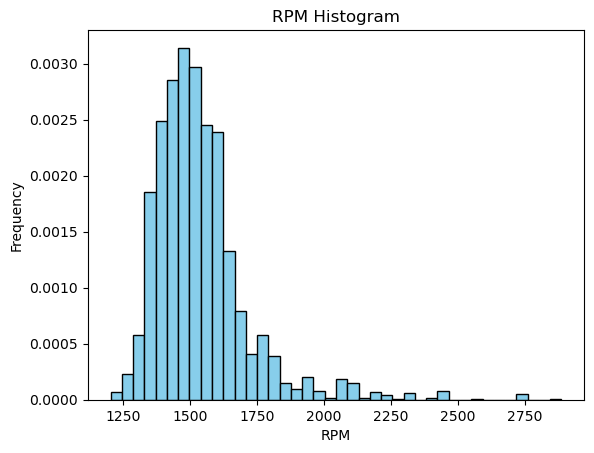

In [61]:
# histogram
import matplotlib.pyplot as plt
import numpy as np
# from matplotlib.ticker import PercentFormatter

# Generate data for the histogram
histogramData = []

for i in rpm:
    histogramData.append(rpm[i])

# Plotting a basic histogram
plt.hist(histogramData, bins=40, density=True, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('RPM')
plt.ylabel('Frequency')
plt.title('RPM Histogram')

# Display the plot
plt.show()

# capture xmin and xmax using the xlim function



### Distribution fit
In the next steps, we want to fit two distributions to the rotational speed data.


### 4. Parameters - Normal Distribution
First, we start with the normal distribution and estimate the normal parameters mean and std. You can use norm.fit from Scipy for this. You can find more information [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html).

In [62]:
# estimate normal parameters
mean, std = norm.fit(histogramData)

#print(mean, std)

### 5. X-values
Create a smooth grid of 100 x-values across the x-axis limits from the histogram you captured in step 3. Fill in the gaps (...) to complete the code. 

In [63]:
# fill in the gaps (...)
x = np.linspace(1000, 3000, 100)
#print(x)

### 6. Probability density function
Create a fitted normal PDF (Probability density function) on that grid using the estimated normal parameters. You can look up and use norm.pdf for this.

In [64]:
# normal probability density function 

NormPdf = norm.pdf(x, loc=mean, scale=std)

### 7. Plot Normal Fit
Overlay the fitted normal curve on the histogram. Use the previously generated x-values for the plot. Set density=True for the histogram.

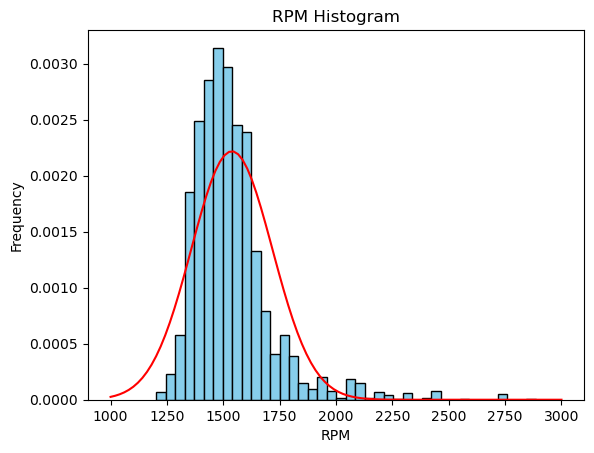

In [65]:
#plt.hist..
plt.hist(histogramData, bins=40, density=True, color='skyblue', edgecolor='black')
#plt.plot..
plt.plot(x, NormPdf, ls='solid', color='red')
#plt.title..
plt.xlabel('RPM')
plt.ylabel('Frequency')
plt.title('RPM Histogram')
#plt.show..


plt.show()

### 8. Compare with Uniform Distribution (Optional)
Next, we fit a uniform distribution just as comparison. Again, we must estimate the parameters of the distribution and then calculate the probability density function. 

In [66]:
# parameters of uniform distribution (uniform.fit)
mean_u, std_u = uniform.fit(histogramData)


In [67]:
# uniform.pdf

uniformpdf = uniform.pdf(x, loc=mean_u, scale=std_u)

Lastly, we plot the two distributions together with the histogram. Do they fit the data? Which one clearly fits better? What other distribution could fit? 

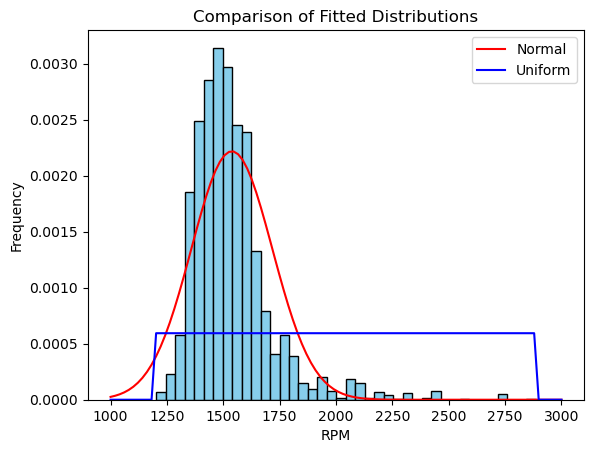

In [68]:
# Plot the data histogram
plt.hist(histogramData, bins=40, density=True, color='skyblue', edgecolor='black')

# Overlay fitted distributions
plt.plot(x, NormPdf, ls='solid', color='red', label = "Normal")
plt.plot(x, uniformpdf, ls='solid', color='blue', label = "Uniform")

plt.xlabel('RPM')
plt.ylabel('Frequency')
plt.title("Comparison of Fitted Distributions")


plt.legend()
plt.show()


